# Fraud Detection Model

This notebook builds a machine learning model to detect fraudulent financial transactions using a Random Forest Classifier.

The dataset contains transaction records from a mobile money service. Although the complete dataset has over 6.3 million transactions, model development was performed on a large representative subset due to computational constraints. The subset preserved the original fraud distribution and was sufficient to derive reliable insights.

**What this notebook covers:**
- Exploratory Data Analysis (EDA)
- Data preprocessing and feature engineering
- Model training with class imbalance handling
- Evaluation using Recall, F1-Score, and ROC-AUC
- Feature importance analysis
- Business recommendations for fraud prevention

## Setup

**To run this notebook on your machine:**

1. Install the required libraries:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn openpyxl
```

2. Run all cells top to bottom

In [1]:
# Importing all required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

## 1. Loading the Dataset

We load the transaction data from an Excel file. The dataset contains financial transactions including the transaction type, amount, sender and receiver balances, and a label indicating whether the transaction was fraudulent.

In [ ]:
# Merging the dataset chunks to a single excel file.
import pandas as pd
import os

def merge_excel_files(input_folder: str, output_file: str) -> None:
    all_files = sorted([f for f in os.listdir(input_folder) if f.endswith(".xlsx")])

    dataframes = []

    for file in all_files:
        file_path = os.path.join(input_folder, file)
        df = pd.read_excel(file_path)
        dataframes.append(df)

    merged_df = pd.concat(dataframes, ignore_index=True)
    merged_df.to_excel(output_file, index=False)

In [28]:
merge_excel_files("dataset_chunks", "transactions.xlsx")

In [29]:
df = pd.read_excel('transactions.xlsx')

In [30]:
# Preview the first few rows to understand the structure
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Random sample to get a feel for the data variety
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
17051,8,CASH_IN,30284.88,C1095778410,102053.0,132337.88,C1122492719,0.00,0.00,0,0
577275,33,CASH_OUT,136138.66,C648984855,0.0,0.00,C575233839,5928773.91,6064912.57,0,0
304487,15,PAYMENT,44631.76,C2076737967,65654.9,21023.14,M1757841233,0.00,0.00,0,0
470498,19,CASH_OUT,248543.34,C1099956239,0.0,0.00,C373339841,279875.64,1578820.81,0,0
811663,40,CASH_IN,10380.32,C1787095088,50126.0,60506.32,C553432448,575062.90,564682.58,0,0


In [5]:
# Check the size of the dataset
df.shape

(1048575, 11)

In [6]:
# Check column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


## 2. Exploratory Data Analysis

Before building any model, we need to understand the data. Key things to check:
- How imbalanced is the fraud label?
- Which transaction types are most associated with fraud?
- How does transaction amount differ between fraud and non-fraud cases?

In [7]:
# Check how many fraudulent vs non-fraudulent transactions exist
# This tells us how severe the class imbalance is
df['isFraud'].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [8]:
# Express as percentage — fraud cases are typically less than 1% of all transactions
# This confirms we need special handling for class imbalance
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64

In [9]:
# List all column names
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## 3. Data Cleaning

**Dropping identifier columns:**
The columns `nameOrig` and `nameDest` are unique customer IDs for the sender and receiver. They have no predictive value for fraud detection — they are just labels, not behavioral signals. Keeping them would not improve the model and could cause data leakage issues.

In [10]:
df = df.drop(columns=['nameOrig', 'nameDest'])
df.shape

(1048575, 9)

## 4. Visualizations

We use a sample of 100,000 rows for visualizations to keep it fast. The sample is drawn randomly with a fixed seed so results are reproducible.

**Why we keep outliers:**
Extreme transaction amounts are actually useful signals here — fraudsters tend to transfer unusually large amounts quickly. Removing outliers would mean throwing away some of our most informative data points.

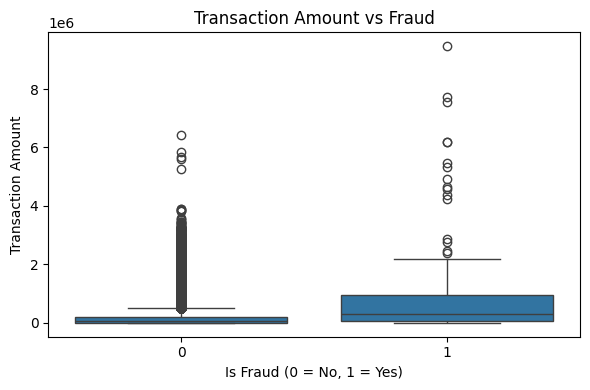

In [11]:
# Use a sample for faster visualization — random_state ensures reproducibility
sample_df = df.sample(100000, random_state=42)

# Transaction amount vs fraud
# We expect fraudulent transactions to have higher and more extreme amounts
plt.figure(figsize=(6, 4))
sns.boxplot(x='isFraud', y='amount', data=sample_df)
plt.title('Transaction Amount vs Fraud')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Transaction Amount')
plt.tight_layout()
plt.show()

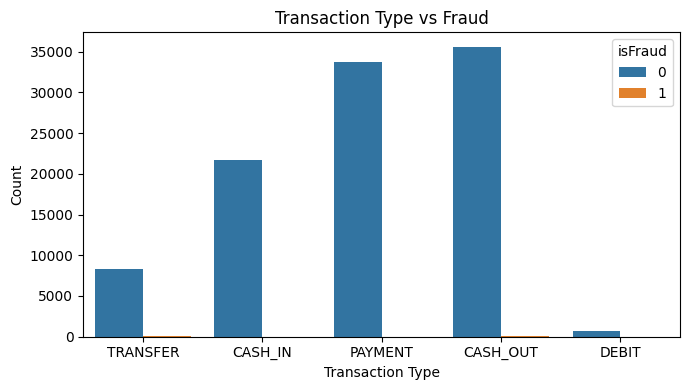

In [12]:
# Transaction type vs fraud
# Fraud is typically concentrated in TRANSFER and CASH_OUT types
# because these are the only ways money can leave the system
plt.figure(figsize=(7, 4))
sns.countplot(x='type', hue='isFraud', data=sample_df)
plt.title('Transaction Type vs Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

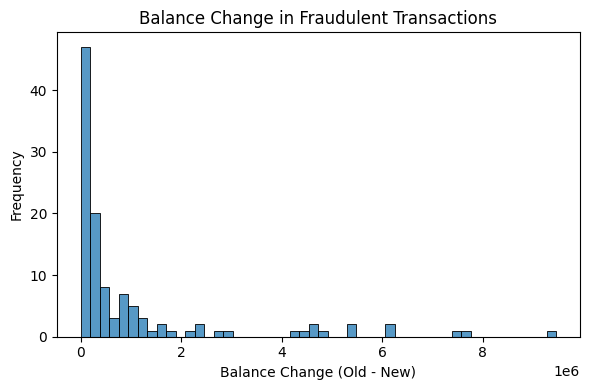

In [13]:
# Balance change in fraudulent transactions
# Fraudsters typically drain the sender's account completely
# so we expect a large balance drop in fraud cases
sample_df['balance_change'] = sample_df['oldbalanceOrg'] - sample_df['newbalanceOrig']

plt.figure(figsize=(6, 4))
sns.histplot(sample_df[sample_df['isFraud'] == 1]['balance_change'], bins=50)
plt.title('Balance Change in Fraudulent Transactions')
plt.xlabel('Balance Change (Old - New)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 5. Preprocessing — Encoding Categorical Variables

The `type` column contains transaction categories as text (TRANSFER, CASH_OUT, PAYMENT, etc.). Machine learning models require numerical inputs, so we use Label Encoding to convert these text labels into integers.

Label Encoding is appropriate here since we are using a tree-based model (Random Forest) which does not assume any ordinal relationship between the encoded values.

In [14]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# Verify encoding
df[['type']].head()

,type
0,3
1,3
2,4
3,1
4,3


## 6. Train-Test Split

We split the data into 70% training and 30% testing.

**Why `stratify=y`?**
Since fraud cases are less than 1% of the data, a random split might put almost all fraud cases in training and very few in testing (or vice versa). `stratify=y` ensures that both train and test sets have the same fraud-to-non-fraud ratio as the original dataset.

In [15]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y       # preserves the fraud ratio in both splits
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (734002, 8)
Testing set:  (314573, 8)


## 7. Model Training — Random Forest Classifier

We use a Random Forest Classifier for the following reasons:
- Handles large datasets efficiently
- Captures non-linear relationships between features
- Robust to outliers (which we intentionally kept)
- Provides feature importance scores for interpretability
- Not affected by multicollinearity between balance variables

**Key parameter — `class_weight='balanced'`:**
This tells the model to automatically assign higher weight to the minority class (fraud). Without this, the model would be biased toward predicting non-fraud for everything since 99%+ of transactions are legitimate. Balanced weights penalize the model more for missing a fraud case than for a false alarm.

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,       # number of trees in the forest
    max_depth=10,           # limits tree depth to prevent overfitting
    random_state=42,        # for reproducibility
    class_weight='balanced', # handles class imbalance
    n_jobs=1                # use 1 CPU core (-1 to use all cores)
)

rf.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 8. Model Evaluation

For fraud detection, **accuracy is a misleading metric**. A model that predicts "not fraud" for every transaction would still achieve 99%+ accuracy — but catch zero fraudsters.

We focus on:
- **Recall (Fraud class)** — what % of actual fraud did we catch? Missing fraud = financial loss
- **Precision** — of what we flagged as fraud, how many were actually fraud? Low precision = too many false alarms
- **ROC-AUC** — overall discriminatory power of the model across all thresholds

In [18]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # probability of fraud for ROC-AUC

In [19]:
# Confusion matrix
# Rows = Actual, Columns = Predicted
# Top-left = True Negatives, Bottom-right = True Positives
# Bottom-left = False Negatives (missed fraud — most costly)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[313391    839]
 [    39    304]]


In [20]:
# Full classification report with precision, recall, and F1 for both classes
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    314230
           1       0.27      0.89      0.41       343

    accuracy                           1.00    314573
   macro avg       0.63      0.94      0.70    314573
weighted avg       1.00      1.00      1.00    314573



In [21]:
# ROC-AUC Score
# 1.0 = perfect model, 0.5 = random guessing
# Score above 0.95 is considered excellent for fraud detection
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9940


## 9. Feature Importance

Random Forest gives us importance scores for each feature — showing which variables had the most influence on the model's predictions. This is useful for both model interpretation and business decision-making.

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

          Feature  Importance
3   oldbalanceOrg    0.222031
0            step    0.175077
4  newbalanceOrig    0.174039
1            type    0.162497
2          amount    0.151983
6  newbalanceDest    0.058003
5  oldbalanceDest    0.056368
7  isFlaggedFraud    0.000000


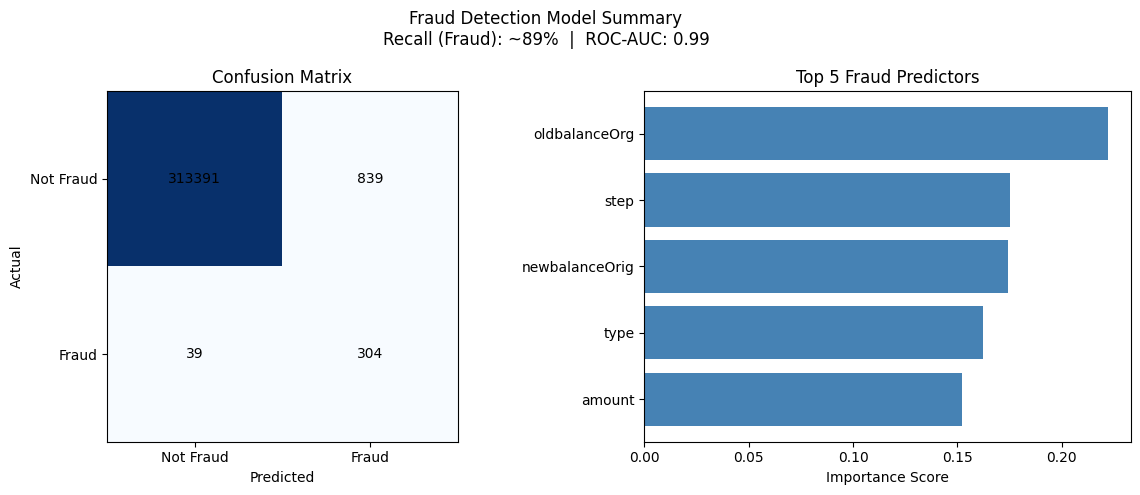

In [23]:
# Visual summary — Confusion Matrix + Top 5 Feature Importance side by side

fi = feature_importance.head(5)

plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.yticks([0, 1], ['Not Fraud', 'Fraud'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

# Feature Importance
plt.subplot(1, 2, 2)
plt.barh(fi['Feature'], fi['Importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Top 5 Fraud Predictors")
plt.xlabel("Importance Score")

plt.suptitle(
    f"Fraud Detection Model Summary\nRecall (Fraud): ~89%  |  ROC-AUC: {auc:.2f}",
    fontsize=12
)

plt.tight_layout()
plt.show()

## 10. Business Analysis — Proactive Fraud Detection Case Study

---

### Q1. Data Cleaning including Missing Values, Outliers, and Multicollinearity

The dataset was checked for missing values and none were found, so no imputation was required. Extreme values were observed in transaction amount and balance-related variables. Since such extremes are typical indicators of fraudulent behaviour, outliers were retained instead of being removed. Identifier columns (`nameOrig`, `nameDest`) were dropped as they do not contribute to prediction. Although some balance variables were correlated, they were kept because the selected tree-based model is not affected by multicollinearity.

---

### Q2. Describe your fraud detection model

A Random Forest Classifier was used to build the fraud detection model. This algorithm was chosen because it can handle large datasets, capture non-linear relationships, and is robust to outliers. It also provides feature importance, which helps in interpreting model decisions. Class imbalance was handled using balanced class weights, and stratified sampling was applied during train-test splitting to preserve the fraud ratio. The model was trained on historical transactions and evaluated on unseen data.

---

### Q3. How did you select variables to be included in the model?

Variables were selected based on domain understanding and model relevance. Transaction amount, type, timing, and balance-related features were retained as they reflect customer behavior. Identifier columns were excluded. Feature importance scores from the Random Forest model were used to confirm the contribution of each selected variable.

---

### Q4. Demonstrate the performance of the model

Given the highly imbalanced nature of fraud data, multiple evaluation metrics were used instead of accuracy alone. The model was evaluated using a confusion matrix, precision, recall, F1-score, and ROC-AUC score. The model achieved a high recall of approximately 89% for fraudulent transactions, indicating that most fraud cases were correctly identified. The ROC-AUC score was approximately 0.99, demonstrating excellent discriminatory power. Recall was prioritized to minimize financial losses due to undetected fraud.

---

### Q5. What are the key factors that predict fraudulent transactions?

Feature importance analysis revealed the most significant predictors of fraud:
- Sender's balance before the transaction (`oldbalanceOrg`)
- Transaction timing (`step`)
- Sender's balance after the transaction (`newbalanceOrig`)
- Transaction type (particularly TRANSFER and CASH_OUT)
- Transaction amount

The rule-based fraud flag (`isFlaggedFraud`) showed negligible importance, indicating the limitations of static threshold-based detection systems.

---

### Q6. Do these factors make sense?

Yes, these factors make strong practical sense. Fraudsters typically gain unauthorized access to accounts and quickly empty funds through transfer or cash-out transactions. Sudden balance drops, large transaction amounts, and abnormal transaction timing are well-known indicators of fraudulent behavior. The identified factors align closely with real-world fraud patterns.

---

### Q7. What prevention strategies should be adopted?

The company should implement real-time fraud scoring, additional authentication for high-risk transactions, transaction velocity checks, and limits for new or low-trust accounts. Monitoring recipient accounts and periodically retraining the model will further strengthen fraud prevention.

---

### Q8. How would you measure if the prevention strategies work?

Effectiveness can be measured by monitoring: reduction in fraud rate, decrease in financial losses, changes in false positive and false negative rates, and overall model stability. A/B testing between old and updated systems can be conducted alongside continuous monitoring for concept drift and periodic model re-evaluation.

---

## Conclusion

This analysis shows that machine learning can effectively detect fraudulent transactions by learning behavioral patterns from historical data. The model achieved strong performance with ~89% fraud recall and 0.99 ROC-AUC, while identifying key risk indicators such as transaction type, amount, and balance changes. These insights support a proactive approach to fraud prevention beyond traditional rule-based systems.